# Import et installation

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

# Chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

#Chargement des données
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

#Affichage des premières lignes et de la forme du DataFrame
print(df.head())
print(df.shape)

#Sélection des variables numériques uniquement
X = df.select_dtypes(include=[np.number])

#Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Application t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    learning_rate='auto',
    init='pca'
)

X_tsne = tsne.fit_transform(X_scaled)

#Conversion en DataFrame
df_tsne = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])

       city_name country  population_density  avg_income  \
0      Old Vista  Europe                2775        3850   
1      Beachport  Europe                3861        3700   
2  Valleyborough  Europe                2562        4310   
3           City  Europe                3192        3970   
4          Falls  Europe                3496        4320   

   internet_penetration  avg_rent  air_quality_index  public_transport_score  \
0                  86.4      1310                 43                    52.0   
1                  78.1      1330                 42                    62.8   
2                  80.1      1330                 39                    73.2   
3                  81.2      1480                 60                    49.2   
4                 100.0      1510                 64                    93.7   

   happiness_score  green_space_ratio  
0              8.5               23.8  
1              8.1               33.1  
2              8.5               40.2 

# Visualisation 2D

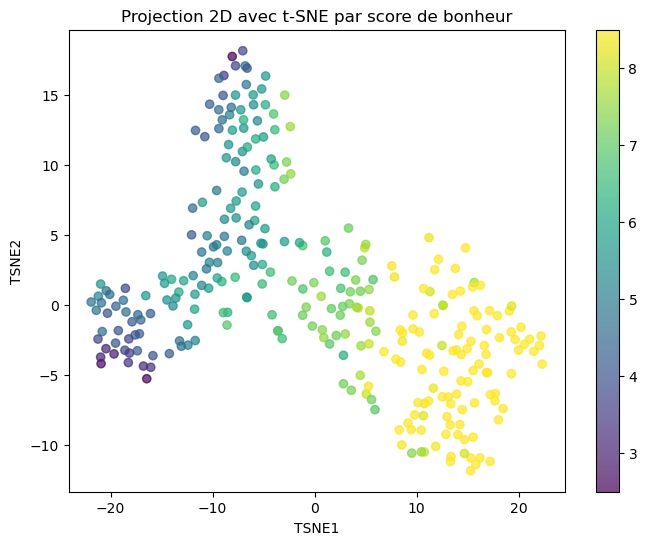

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_tsne["TSNE1"],
    df_tsne["TSNE2"],
    c=df["happiness_score"],
    cmap="viridis",
    alpha=0.7
)
plt.colorbar()
plt.title("Projection 2D avec t-SNE par score de bonheur")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

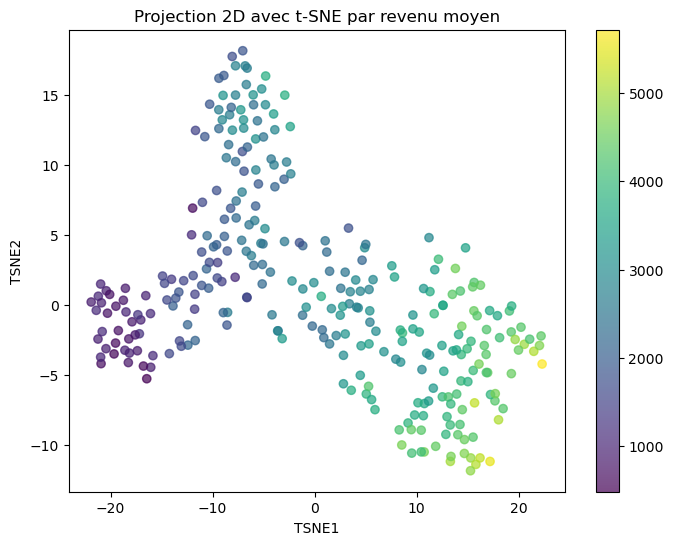

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_tsne["TSNE1"],
    df_tsne["TSNE2"],
    c=df["avg_income"],
    cmap="viridis",
    alpha=0.7
)
plt.colorbar()
plt.title("Projection 2D avec t-SNE par revenu moyen")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

Sur ce graphique t‑SNE, on observe que les pays à faible revenu moyen sont regroupés à gauche avec des couleurs plutôt sombres, tandis que les pays à revenu plus élevé se trouvent progressivement vers la droite et prennent des teintes plus claires allant du vert au jaune, ce qui met en évidence un gradient continu du niveau de richesse le long de l’axe horizontal.

# Export des données 2D

In [5]:
df_tsne.to_csv("../outputs/tsne_emb_2d.csv", index=False)

La projection t‑SNE montre plusieurs groupes bien séparés, ce qui suggère une structure complexe et non linéaire dans les données. La méthode semble bien conserver la proximité entre les points voisins, mais les distances entre les différents groupes doivent être interprétées avec prudence, car elles ne reflètent pas forcément des écarts importants entre les observations.